# TESSERA Master Notebook v4
**Objective**: Orchestrate the TESSERA preprocessing and inference pipeline.

This notebook calls functions defined in `V4_TESSERA_Worker.ipynb` to perform environment setup and per-tile processing.

In [2]:
import nbformat
from IPython import get_ipython
from pathlib import Path
import sys, os

def run_notebook_inplace(path, clear_functions=True):
    """Execute all code cells from a notebook in the current runtime."""
    if not Path(path).exists():
        raise FileNotFoundError(f"Notebook not found at: {path}")

    nb = nbformat.read(open(path), as_version=4)
    shell = get_ipython()

    if clear_functions:
        # Parse all function/class names defined in the notebook and delete them
        import ast
        for cell in nb.cells:
            if cell.cell_type != "code":
                continue
            try:
                tree = ast.parse(cell.source)
                for node in ast.walk(tree):
                    if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
                        if node.name in shell.user_ns:
                            del shell.user_ns[node.name]
            except SyntaxError:
                pass  # skip unparseable cells

    for cell in nb.cells:
        if cell.cell_type == "code":
            shell.run_cell(cell.source)

    print(f"✅ Executed notebook in current kernel: {path}")

# ── Path Logic for Link ──
# Flag: switch between production (shared drive) and local testing
#run_production = False  # <-- Use for private or local testing
#run_production = True   # <-- Use for production deployment

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    # if run_production:
        # Placeholder for production path structure if different
    #worker_dir = Path('/content/drive/MyDrive/TESSERA_PROD/REPO/local_work/notebooks-test/')
    # else:
    worker_dir = Path('/content/drive/MyDrive/Colab Notebooks/TESSERA/')
else:
    # Local system
    worker_dir = Path('./')

worker_file = "V4_TESSERA_Worker.ipynb"
WORKER_PATH = worker_dir / worker_file

# Link to the worker now:
run_notebook_inplace(WORKER_PATH)

# Set to true for a new area/period:
booRun = True # False

Mounted at /content/drive
✅ Executed notebook in current kernel: /content/drive/MyDrive/Colab Notebooks/TESSERA/V4_TESSERA_Worker.ipynb


### Step 1 — Runtime check

In [3]:
check_runtime()


========== System ==========
Python   : 3.12.12
OS       : Linux 6.6.113+

========== GPU ==========
GPU      : NVIDIA L4, 23034 MiB
Sun Mar 22 22:37:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   41C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|     

### Step 2 — Install dependencies

In [4]:
install_dependencies()

import numpy as np
import rasterio
import pyproj
import rioxarray, xarray, stackstac, dask
import subprocess, time, threading
import pystac_client, planetary_computer

from rasterio.transform import from_bounds
from rasterio.crs import CRS
from pyproj import Transformer
from shapely.geometry import box

print(f"rasterio   : {rasterio.__version__}")
print(f"xarray     : {xarray.__version__}")
print(f"stackstac  : {stackstac.__version__}")
print(f"dask       : {dask.__version__}")
print(f"pyproj     : {pyproj.__version__}")
print("All core imports OK.")

Checking core dependencies...
Installing: affine, dask[distributed], fiona, pyproj, rasterio, rioxarray, shapely, stackstac, xarray, pystac-client, pystac, planetary-computer, gdown, tqdm...
Installation completed successfully.
rasterio   : 1.5.0
xarray     : 2026.2.0
stackstac  : 0.5.1
dask       : 2026.1.1
pyproj     : 3.7.2
All core imports OK.


### Step 3 — Mount Drive & set paths

In [5]:
# Configures the base paths for data and repo
global_paths = setup_paths(in_colab=IN_COLAB)

Paths configured:
  Drive base  : /content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline
  Repo        : /content/drive/MyDrive/Colab Notebooks/TESSERA/REPO
  Data        : /content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/data
  Temp        : /content/tmp_tessera
  Checkpoint  : /content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/checkpoints
  Output      : /content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/output
  Dates       : {}


### Step 4 — Clone TESSERA repository

In [6]:
# Clone logic from v3 with FORCE_RECLONE enabled
clone_tessera_repo(repo_dir=global_paths.REPO_DIR,
                   FORCE_RECLONE=False,
                   BRANCH='alpha_version_1.0')

Repo already present at: /content/drive/MyDrive/Colab Notebooks/TESSERA/REPO
Active branch: alpha_version_1.0
REPO_DIR in sys.path: True


### Step 5 — Apply SCL patch (thin cirrus)

In [7]:
# Apply the cloud masking patch defined in the worker
apply_scl_patch(repo_dir=global_paths.REPO_DIR)

SCL_INVALID before patch: {0, 1, 2, 3, 8, 9, np.nan, 10}
SCL patch already applied (class 10 present).
Verified: SCL_INVALID = {0, 1, 2, 3, 8, 9, np.nan, 10}


### Step 6 — Set executable permissions on binaries & scripts

In [8]:
# Set permissions for shell scripts and Rust binaries
# ── Call it ───────────────────────────────────────────────────────────
set_permissions(repo_dir=global_paths.REPO_DIR)

Setting executable permissions:
  ✓  tessera_preprocessing/s1_s2_downloader.sh
  ✓  tessera_preprocessing/s1_s2_stacker.sh
  ✓  tessera_infer/infer_all_tiles.sh
  ✓  tessera_preprocessing/s1_stack
  ✓  tessera_preprocessing/s2_stack


### Step 7 — Inference Setup


In [9]:
# Localize checkpoint and patch launch scripts
# ── Call it ───────────────────────────────────────────────────────────
# using: ckpt_filename: str = 'best_model_fsdp_20250427_084307.pt')
if booRun:
    global_paths.CKPT_LOCAL = setup_inference(repo_dir=global_paths.REPO_DIR,
                                          checkpoint_dir=global_paths.CHECKPOINT,
                                          in_colab=IN_COLAB)
else:
    print("Skipping inference setup.")

Searching Drive for 'best_model_fsdp_20250427_084307.pt'...
  Found: /content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/checkpoints/best_model_fsdp_20250427_084307.pt
  Copying to /content/ for faster load (no spaces)...
  Done — 7163 MB
PYTHON_ENV already patched.


## Pipeline Configuration

In [10]:
# Link to the worker to collect any last minute changes:
run_notebook_inplace(WORKER_PATH)
# global_paths = setup_paths(in_colab=IN_COLAB)
print(global_paths)

✅ Executed notebook in current kernel: /content/drive/MyDrive/Colab Notebooks/TESSERA/V4_TESSERA_Worker.ipynb
namespace(DRIVE_BASE=PosixPath('/content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline'), REPO_DIR=PosixPath('/content/drive/MyDrive/Colab Notebooks/TESSERA/REPO'), DATA_DIR=PosixPath('/content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/data'), TEMP_DIR=PosixPath('/content/tmp_tessera'), CHECKPOINT=PosixPath('/content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/checkpoints'), OUTPUT_DIR=PosixPath('/content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/output'), acquisition_dates={}, CKPT_LOCAL=PosixPath('/content/checkpoint.pt'))


In [11]:
AREAS = {
    "Soubre_Test_Tile": {
        "lon": -6.60,
        "lat": 5.78,
        "size_m": 5000,
        "res": 10.0,
        "epsg": 32630
    }
}

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]

THRESHOLDS = list(range(5, 105, 5))  # 5, 10, 15, ... 100

In [13]:
# Running the TESSERA Pipeline
MIN_SCENES = 7 # minimum S2 scenes required to proceed

# Running the TESSERA Pipeline
booRun = False
if booRun:
    for i, (area_name, params) in enumerate(AREAS.items()):
        print(f"\n=== Area: {area_name} ===")
        # Step 8: Generate ROI for this area
        roi_path = worker_step_roi(area_name, params, global_paths)

        for j, year in enumerate(YEARS):
            print(f"--- Processing {year} ---")

            # Check scene availability before committing to download
            dates = query_s2_dates(roi_path, year, max_cloud=35)
            global_paths.acquisition_dates[(area_name, year)] = dates
            print(f"  S2 scenes available: {len(dates)}  ({dates[0]} → {dates[-1]})" if dates else "  S2 scenes available: 0")

            if len(dates) < MIN_SCENES:
                print(f"  ⚠️  Skipping {area_name} {year} — insufficient scenes ({len(dates)} < {MIN_SCENES})")
                continue

            # Step 9-15: Execute worker for this specific period
            verbose = (i == 0 and j == 0)
            run_worker_pipeline(area_name, params, year, roi_path, global_paths,
                                verbose, max_cloud=35)
else:
    print("Skipping pipeline execution.")

Skipping pipeline execution.


In [14]:
global_paths.acquisition_dates

{('Soubre_Test_Tile', 2020): ['2020-01-03',
  '2020-01-13',
  '2020-02-07',
  '2020-02-22',
  '2020-05-02',
  '2020-05-12',
  '2020-06-01',
  '2020-11-08',
  '2020-11-13',
  '2020-12-18']}

In [15]:
booRun = False

if booRun:
    # ── Cloud cover threshold experiment ─────────────────────────────────
    AREA_NAME  = 'Soubre_Test_Tile'
    TEST_YEAR  = 2023
    THRESHOLDS = list(range(5, 105, 5))  # 5, 10, 15, ... 100

    print(f"Querying S2 scene availability for {AREA_NAME} {TEST_YEAR}")
    print(f"{'Threshold':>10}  {'Scenes':>6}  Dates")
    print("-" * 60)

    roi_path = global_paths.DATA_DIR / f'{AREA_NAME}_roi.tif'

    threshold_results = {}
    for threshold in THRESHOLDS:
        dates = query_s2_dates(roi_path, TEST_YEAR, max_cloud=threshold)
        threshold_results[threshold] = dates
        date_str = ', '.join(dates) if dates else '—'
        print(f"{threshold:>9}%  {len(dates):>6}  {date_str}")

In [16]:
import json
from datetime import datetime, timedelta
booRun = False
if booRun:
    # ── Cloud cover threshold experiment ─────────────────────────────────
    AREA_NAME  = 'Soubre_Test_Tile'
    TEST_YEAR  = 2023
    THRESHOLDS = list(range(15, 95, 5))  # 15, 20,..., 85, 90
    CHECKPOINT_PATH = global_paths.OUTPUT_DIR / AREA_NAME / 'cloud_threshold_experiment.json'

    # Load existing results if resuming
    if CHECKPOINT_PATH.exists():
        with open(CHECKPOINT_PATH) as f:
            results = json.load(f)
        results = {int(k): v for k, v in results.items()}
        print(f"Resuming from checkpoint — {len(results)} thresholds already done.")
        print(f"Remaining: {[t for t in THRESHOLDS if t not in results]}")
    else:
        results = {}
        print("Starting fresh experiment.")

    roi_path = global_paths.DATA_DIR / f'{AREA_NAME}_roi.tif'
    params   = AREAS[AREA_NAME]

    for threshold in THRESHOLDS:
        if threshold in results:
            print(f"[{threshold}%] Already done, skipping.")
            continue

        print(f"\n[{threshold}%] Starting...  {datetime.now().strftime('%H:%M:%S')}")

        try:
            run_worker_pipeline(
                name      = AREA_NAME,
                params    = params,
                year      = TEST_YEAR,
                roi_path  = roi_path,
                paths     = global_paths,
                verbose   = False,
                max_cloud = threshold,
                chunksize = 1024
            )

            # Save checkpoint
            results[threshold] = {'completed_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
            with open(CHECKPOINT_PATH, 'w') as f:
                json.dump(results, f, indent=2)
            print(f"  ✓  Checkpoint saved.")

        except Exception as e:
            print(f"  ✗  Failed at {threshold}%: {e}")
            with open(CHECKPOINT_PATH, 'w') as f:
                json.dump(results, f, indent=2)

Loading embeddings...
  ✓ 2020  shape=(250000, 128)
  ✓ 2021  shape=(250000, 128)
  ✓ 2022  shape=(250000, 128)
  ✓ 2023  shape=(250000, 128)
  ✓ 2024  shape=(250000, 128)
  ✓ 2025  shape=(250000, 128)

Fitting PCA across all years...
Variance explained by 3 PCs: 42.3%
Per component: [22.855589  11.533327   7.9385996]
  ✓ PCA applied: 2020
  ✓ PCA applied: 2021
  ✓ PCA applied: 2022
  ✓ PCA applied: 2023
  ✓ PCA applied: 2024
  ✓ PCA applied: 2025

Generating GIF...
✓ GIF saved: /content/drive/MyDrive/Colab Notebooks/TESSERA/Cocoa_Detection_Pipeline/output/Soubre_Test_Tile/TESSERA_Soubre_Test_Tile_2020_2025_pca_t035.gif


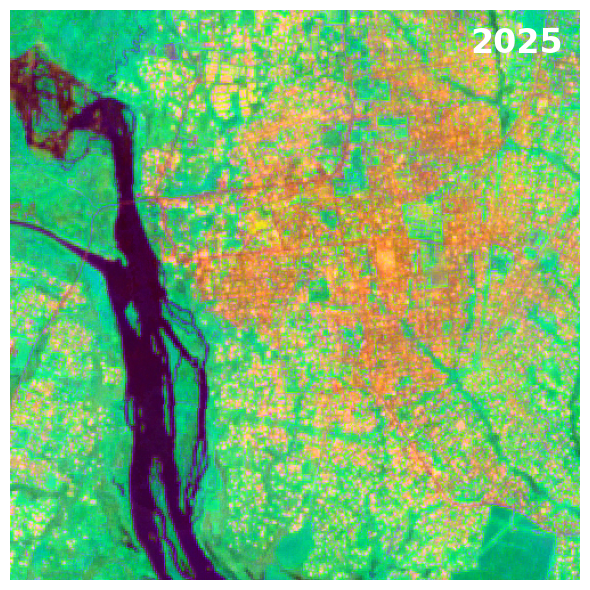

In [18]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.decomposition import PCA
from pathlib import Path

AREA_NAME = 'Soubre_Test_Tile'
YEARS     = [2020, 2021, 2022, 2023, 2024, 2025]

# ── 1. Load all years ─────────────────────────────────────────────────
print("Loading embeddings...")
embeddings = {}
for year in YEARS:
    tif = global_paths.OUTPUT_DIR / AREA_NAME / f'TESSERA_{AREA_NAME}_{year}_t035_embed.tif'
    if not tif.exists():
        print(f"  ✗ Missing: {tif.name}")
        continue
    with rasterio.open(tif) as src:
        data = src.read()  # (128, 500, 500)
    H, W = data.shape[1], data.shape[2]
    embeddings[year] = data.reshape(128, -1).T  # (250000, 128)
    print(f"  ✓ {year}  shape={embeddings[year].shape}")

# ── 2. Fit PCA once across all years combined ─────────────────────────
print("\nFitting PCA across all years...")
all_pixels = np.vstack(list(embeddings.values()))  # (N*250000, 128)
pca = PCA(n_components=3)
pca.fit(all_pixels)
print(f"Variance explained by 3 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Per component: {pca.explained_variance_ratio_ * 100}")

# ── 3. Transform each year and stretch ───────────────────────────────
def stretch(arr):
    p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
    return np.clip((arr - p2) / (p98 - p2), 0, 1)

rgb_by_year = {}
for year, pixels in embeddings.items():
    rgb = pca.transform(pixels).reshape(H, W, 3)
    rgb_by_year[year] = np.stack([stretch(rgb[:,:,i]) for i in range(3)], axis=-1)
    print(f"  ✓ PCA applied: {year}")

# ── 4. Generate GIF ───────────────────────────────────────────────────
print("\nGenerating GIF...")
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')
plt.tight_layout()

frames = []
for year, rgb in rgb_by_year.items():
    im = ax.imshow(rgb, animated=True)
    label = ax.text(
        0.97, 0.97,
        str(year),
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=24,
        fontweight='bold',
        color='white',
        animated=True
    )
    frames.append([im, label])

ani = animation.ArtistAnimation(fig, frames, interval=1000, blit=True)

gif_path = global_paths.OUTPUT_DIR / AREA_NAME / f'TESSERA_{AREA_NAME}_2020_2025_pca_t035.gif'
ani.save(gif_path, writer='pillow', dpi=100, savefig_kwargs={'facecolor': 'white'})
print(f"✓ GIF saved: {gif_path}")
plt.show()

In [20]:
# ── 5. Figure 6 — 2021 t020 vs t035 side by side ─────────────────────
print("\nGenerating Figure 6...")

# Load t020 for 2021
tif_t020 = global_paths.OUTPUT_DIR / AREA_NAME / f'TESSERA_{AREA_NAME}_2023_t020_embed.tif'
with rasterio.open(tif_t020) as src:
    data_t020 = src.read()
pixels_t020 = data_t020.reshape(128, -1).T
rgb_t020 = pca.transform(pixels_t020).reshape(H, W, 3)
rgb_t020 = np.stack([stretch(rgb_t020[:,:,i]) for i in range(3)], axis=-1)

# t035 for 2021 already in rgb_by_year
rgb_t035 = rgb_by_year[2021]

fig6, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (label, rgb) in zip(axes, [
    ('t020  (7 scenes)', rgb_t020),
    ('t035  (10 scenes)', rgb_t035)
]):
    ax.imshow(rgb)
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.suptitle('2021 — same area, same year, same model', fontsize=12, y=1.02)
plt.tight_layout()

fig6_path = global_paths.OUTPUT_DIR / AREA_NAME / 'Figure6_2021_t020_vs_t035.png'
plt.savefig(fig6_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f"✓ Figure 6 saved: {fig6_path}")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

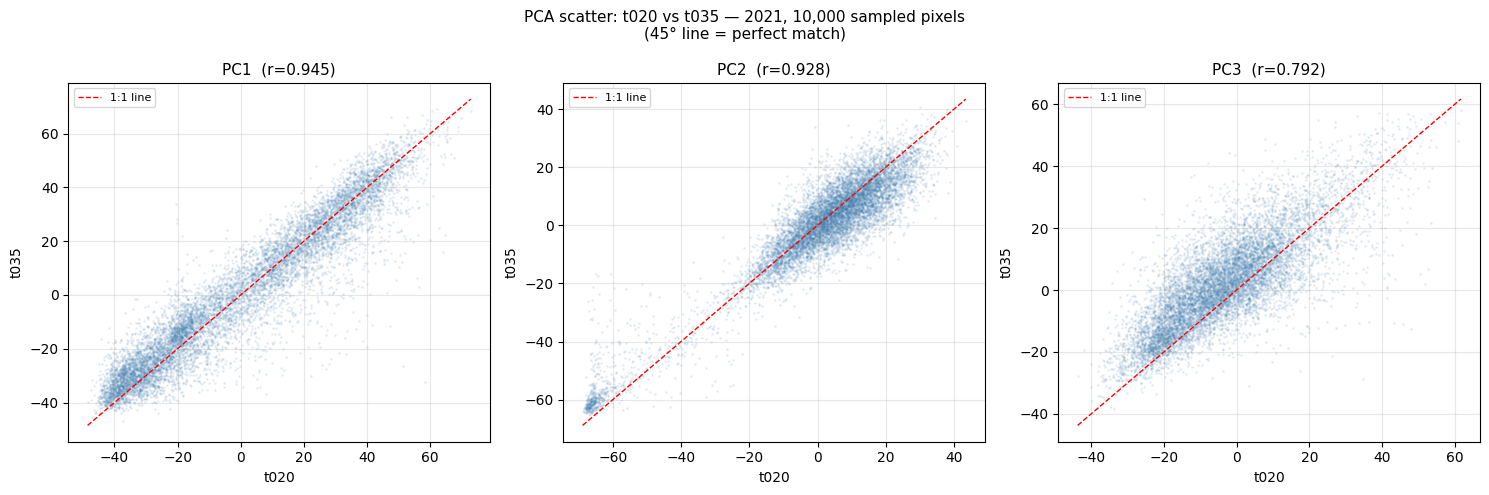

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Get PCA projections for both
pca_t020 = pca.transform(pixels_t020)  # (250000, 3)
pca_t035 = pca.transform(embeddings[2021])  # (250000, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pc_labels = ['PC1', 'PC2', 'PC3']
for i, (ax, label) in enumerate(zip(axes, pc_labels)):
    # Sample 10000 pixels for speed
    idx = np.random.choice(250000, 10000, replace=False)
    x = pca_t020[idx, i]
    y = pca_t035[idx, i]

    ax.scatter(x, y, alpha=0.1, s=1, color='steelblue')

    # 45 degree reference line
    lim = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='1:1 line')

    # Correlation
    corr = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'{label}  (r={corr:.3f})', fontsize=11)
    ax.set_xlabel('t020', fontsize=10)
    ax.set_ylabel('t035', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('PCA scatter: t020 vs t035 — 2021, 10,000 sampled pixels\n(45° line = perfect match)', fontsize=11)
plt.tight_layout()
plt.show()

In [28]:
# Load 2023 t020 and t035
tif_2023_t020 = global_paths.OUTPUT_DIR / AREA_NAME / f'TESSERA_{AREA_NAME}_2024_embed.tif'
tif_2023_t035 = global_paths.OUTPUT_DIR / AREA_NAME / f'TESSERA_{AREA_NAME}_2024_t035_embed.tif'

with rasterio.open(tif_2023_t020) as src:
    data_t020 = src.read().astype(np.float32)
with rasterio.open(tif_2023_t035) as src:
    data_t035 = src.read().astype(np.float32)

H, W = data_t020.shape[1], data_t020.shape[2]
pixels_t020 = data_t020.reshape(128, -1).T  # (250000, 128)
pixels_t035 = data_t035.reshape(128, -1).T  # (250000, 128)

# Fit PCA on both combined
pca_2023 = PCA(n_components=3)
pca_2023.fit(np.vstack([pixels_t020, pixels_t035]))
print(f"Variance explained: {pca_2023.explained_variance_ratio_.sum()*100:.1f}%")

# Project both into shared colour space
rgb_t020 = pca_2023.transform(pixels_t020).reshape(H, W, 3)
rgb_t035 = pca_2023.transform(pixels_t035).reshape(H, W, 3)
rgb_t020 = np.stack([stretch(rgb_t020[:,:,i]) for i in range(3)], axis=-1)
rgb_t035 = np.stack([stretch(rgb_t035[:,:,i]) for i in range(3)], axis=-1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (label, rgb) in zip(axes, [
    ('t020  (3 scenes)', rgb_t020),
    ('t035  (8 scenes)', rgb_t035)
]):
    ax.imshow(rgb)
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.suptitle('2024 — t020 vs t035, shared PCA colour space', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [29]:
YEARS_PLOT      = [2023, 2024, 2025]
THRESHOLDS_PLOT = [20, 35]

# Load all 6 embeddings
embeddings_grid = {}
for year in YEARS_PLOT:
    for t in THRESHOLDS_PLOT:
        if t == 20:
            tif = global_paths.OUTPUT_DIR / AREA_NAME / f'TESSERA_{AREA_NAME}_{year}_embed.tif'
        else:
            tif = global_paths.OUTPUT_DIR / AREA_NAME / f'TESSERA_{AREA_NAME}_{year}_t{str(t).zfill(3)}_embed.tif'

        if not tif.exists():
            print(f"  ✗ Missing: {tif.name}")
            continue

        with rasterio.open(tif) as src:
            data = src.read().astype(np.float32)
        embeddings_grid[(year, t)] = data.reshape(128, -1).T
        print(f"  ✓ {year} t{t:03d}  {tif.name}")

  ✓ 2023 t020  TESSERA_Soubre_Test_Tile_2023_embed.tif
  ✓ 2023 t035  TESSERA_Soubre_Test_Tile_2023_t035_embed.tif
  ✓ 2024 t020  TESSERA_Soubre_Test_Tile_2024_embed.tif
  ✓ 2024 t035  TESSERA_Soubre_Test_Tile_2024_t035_embed.tif
  ✓ 2025 t020  TESSERA_Soubre_Test_Tile_2025_embed.tif
  ✓ 2025 t035  TESSERA_Soubre_Test_Tile_2025_t035_embed.tif


In [30]:
YEARS_PLOT = [2023, 2024, 2025]
THRESHOLDS_PLOT = [20, 35]

# # Load all 6 embeddings
# embeddings_grid = {}
# for year in YEARS_PLOT:
#     for t in THRESHOLDS_PLOT:
#         tif = global_paths.OUTPUT_DIR / AREA_NAME / f'TESSERA_{AREA_NAME}_{year}_t{str(t).zfill(3)}_embed.tif'
#         with rasterio.open(tif) as src:
#             data = src.read().astype(np.float32)
#         embeddings_grid[(year, t)] = data.reshape(128, -1).T
#         print(f"  ✓ {year} t{t:03d}")

# Fit PCA across all 6 combined
pca_grid = PCA(n_components=3)
pca_grid.fit(np.vstack(list(embeddings_grid.values())))
print(f"Variance explained: {pca_grid.explained_variance_ratio_.sum()*100:.1f}%")

# Project and stretch
rgb_grid = {}
for key, pixels in embeddings_grid.items():
    rgb = pca_grid.transform(pixels).reshape(H, W, 3)
    rgb_grid[key] = np.stack([stretch(rgb[:,:,i]) for i in range(3)], axis=-1)

# Plot 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for row, t in enumerate(THRESHOLDS_PLOT):
    for col, year in enumerate(YEARS_PLOT):
        ax = axes[row, col]
        ax.imshow(rgb_grid[(year, t)])
        ax.set_title(f'{year} — t{t:03d}', fontsize=12)
        ax.axis('off')

# Row labels
axes[0, 0].set_ylabel('t020', fontsize=13, labelpad=10)
axes[1, 0].set_ylabel('t035', fontsize=13, labelpad=10)

plt.suptitle('TESSERA embeddings — shared PCA colour space\n2023–2025 at t020 and t035', fontsize=13)
plt.tight_layout()

fig_path = global_paths.OUTPUT_DIR / AREA_NAME / 'Figure6_grid_2x3.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {fig_path}")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
print(f'TESSERA embeddings — PCA RGB\n{AREA_NAME} {year}, 5×5km')

In [ ]:
import numpy as np
from pathlib import Path

bands = Path('/content/tmp_tessera/stacked_output/bands.npy')
arr = np.load(bands)
print(f"Shape: {arr.shape}  (expected (4, 500, 500, 10) for 5/10% threshold)")
print(f"N scenes: {arr.shape[0]}")

In [ ]:
import inspect
#run_notebook_inplace(WORKER_PATH)
#worker_step_cleanup(global_paths, keep_download=False)
#rint(inspect.getsource(worker_step_download_s2))
#print(inspect.getsource(run_worker_pipeline))
print(inspect.getsource(worker_step_cleanup))

In [ ]:
THRESHOLDS = list(range(90, 10, -5))  # 100, 95, 90, ... 5

In [ ]:
THRESHOLDS

In [ ]:
AREA_NAME  = 'Soubre_Test_Tile'
YEARS      = [2020, 2021, 2022, 2023, 2024, 2025]
THRESHOLDS = list(range(5, 105, 5))
MIN_SCENES = 7  # minimum for meaningful embedding based on our experiment

roi_path = global_paths.DATA_DIR / f'{AREA_NAME}_roi.tif'

print(f"{'Year':>6}  ", end='')
for t in THRESHOLDS:
    print(f"{t:>4}", end='')
print()
print("-" * (8 + 4 * len(THRESHOLDS)))

year_results = {}
for year in YEARS:
    print(f"{year:>6}  ", end='')
    year_results[year] = {}
    first_sufficient = None

    for t in THRESHOLDS:
        dates = query_s2_dates(roi_path, year, max_cloud=t)
        n = len(dates)
        year_results[year][t] = n

        if n >= MIN_SCENES and first_sufficient is None:
            first_sufficient = t

        # Mark: ✓ if >= MIN_SCENES, number if not
        if n >= MIN_SCENES:
            print(f"{n:>4}", end='')
        else:
            print(f" {'·':>3}", end='')

    print(f"  → first ≥{MIN_SCENES} scenes at {first_sufficient}%")

In [17]:
AREA_NAME  = 'Soubre_Test_Tile'
YEARS      = [2020, 2021, 2022, 2023, 2024, 2025]
THRESHOLDS = list(range(5, 105, 5))
MIN_SCENES = 7

roi_path = global_paths.DATA_DIR / f'{AREA_NAME}_roi.tif'

print(f"{'Year':>6}  ", end='')
for t in THRESHOLDS:
    print(f"{t:>4}", end='')
print()
print("-" * (8 + 4 * len(THRESHOLDS)))

year_results = {}
for year in YEARS:
    print(f"{year:>6}  ", end='')
    year_results[year] = {}
    first_sufficient = None

    for t in THRESHOLDS:
        dates = query_s2_dates(roi_path, year, max_cloud=t)
        n = len(dates)
        year_results[year][t] = n

        if n >= MIN_SCENES and first_sufficient is None:
            first_sufficient = t

        print(f"{n:>4}", end='')

    print(f"  → first ≥{MIN_SCENES} scenes at {first_sufficient}%")

  Year     5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90  95 100
----------------------------------------------------------------------------------------
  2020     2   2   4   4   6   8  10  13  20  24  25  34  37  41  44  49  50  55  61  72  → first ≥7 scenes at 30%
  2021     1   1   1   2   6  10  12  17  20  23  25  28  31  34  36  40  42  50  56  66  → first ≥7 scenes at 30%
  2022     1   1   4   4   7   8  11  13  14  17  17  19  21  23  24  28  32  42  52  71  → first ≥7 scenes at 25%
  2023     4   4   4   7   8   8  11  13  16  18  21  25  27  35  38  44  48  53  57  73  → first ≥7 scenes at 20%
  2024     1   3   3   3   3   7   8   9  15  18  20  20  22  28  31  37  38  42  45  68  → first ≥7 scenes at 30%
  2025     0   0   1   2   5   7   9  11  14  15  17  18  25  31  38  40  46  55  62  92  → first ≥7 scenes at 30%
